# TorchSig Models Demo

TorchSig Workshop: GRCon 2026

09/22/2026

*Highly recommend changing runtime to T4 GPU.*

https://github.com/TorchDSP/torchsig-models

## Install Dependencies

In [1]:
!pip install -q git+https://github.com/TorchDSP/torchsig-models.git@v1.0.0


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install -q "jupyterlab>=4.0" "matplotlib>=3.7" "scipy>=1.10" "PyYAML>=6.0" "scikit-learn>=1.3"


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

import torchsig_models
from torchsig.datasets.datasets import StaticTorchSigDataset, TorchSigDatasetConfig
from torchsig.transforms.transforms import ComplexTo2D
from torchsig.utils.defaults import TorchSigDefaults
from torchsig.utils.file_handlers import SigMFReader
from torchsig_models.models import XCiTClassifier
from torchsig_models.models.iq_models.efficientnet.efficientnet1d_inference import efficientnet1d_inference
from torchsig_models.models.iq_models.efficientnet.efficientnet1d_train import train_efficientnet_iq
from torchsig_models.utils.training import evaluate_classifier, set_deterministic

assert torchsig_models.__version__ == '1.0.0'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUNS = Path('runs/v1_iq_tutorial')
set_deterministic(2026)
print(f'TorchSig Models {torchsig_models.__version__}; device={DEVICE}')

/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/ereoh/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


TorchSig Models 1.0.0; device=cpu


## 1. Introduction
An RF recording is a sequence of complex samples. We split each sample into its real, in-phase component (**I**) and imaginary, quadrature component (**Q**). Those are the two traces in the first plot.The second plot turns the same signal into a spectrogram, which makes the rising frequency easy for us to recognize. It is a useful diagnostic, but don't feed it to this model: the v1.0 EfficientNet and XCiT examples both expect IQ tensors shaped like `[batch, 2, samples]`.



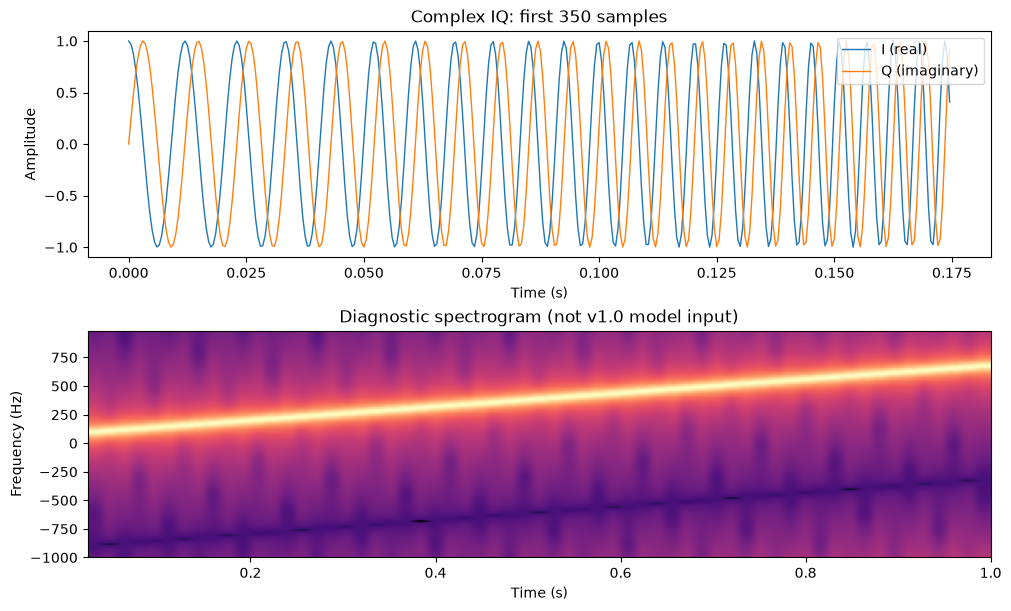

In [4]:
sample_rate = 2_000
time = np.arange(2_048) / sample_rate
frequency_slope = (700 - 80) / time[-1]
phase = 2 * np.pi * (80 * time + 0.5 * frequency_slope * time**2)
example_iq = np.exp(1j * phase)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
axes[0].plot(time[:350], example_iq.real[:350], label='I (real)', linewidth=1)
axes[0].plot(time[:350], example_iq.imag[:350], label='Q (imaginary)', linewidth=1)
axes[0].set(title='Complex IQ: first 350 samples', xlabel='Time (s)', ylabel='Amplitude')
axes[0].legend(loc='upper right')
axes[1].specgram(example_iq, NFFT=128, Fs=sample_rate, noverlap=96, cmap='magma')
axes[1].set(title='Diagnostic spectrogram (not v1.0 model input)', xlabel='Time (s)', ylabel='Frequency (Hz)')
plt.show()

## 2. Tell TorchSig what to generate
Now we'll describe our dataset once and reuse that description for three independent splits. A `TorchSigDatasetConfig` controls things such as capture length, sample rate, SNR, signal duration, and output representation. Changing the seed for each split gives us different examples for training, validation, and testing.

To keep the demo approachable, we'll distinguish just `tone` from `lfm-radar`. Every capture contains one long, high-SNR signal, and `output_representation='iq'` asks TorchSig to return two-channel IQ. This is a pipeline check, not a realistic benchmark; a production experiment should cover the classes, impairments, and SNR range it will encounter.

In [5]:
SIGNALS = ['tone', 'lfm-radar']

def make_config(length: int, seed: int) -> TorchSigDatasetConfig:
    metadata = TorchSigDefaults().default_dataset_metadata.copy()
    metadata.update({
        'sample_rate': 10_000_000,
        'num_iq_samples_dataset': 4096,
        'fft_size': 64,
        'fft_stride': 64,
        'num_signals_min': 1,
        'num_signals_max': 1,
        'cochannel_overlap_probability': 0.0,
        'snr_db_min': 20.0,
        'snr_db_max': 40.0,
        'noise_power_db': 0.0,
        'signal_duration_in_samples_min': 3600,
        'signal_duration_in_samples_max': 4096,
        'bandwidth_min': 1_500_000,
        'bandwidth_max': 2_000_000,
        'signal_center_freq_min': -2_500_000,
        'signal_center_freq_max': 2_499_999,
        'frequency_min': -2_500_000,
        'frequency_max': 2_499_999,
    })
    return TorchSigDatasetConfig(
        dataset_id='efficientnet_iq_tutorial', dataset_length=length, seed=seed,
        impairment_level=0, output_representation='iq',
        output_spectrogram_fft=64,  # Required by the config schema; unused for IQ output.
        signal_sampling_mode='per_signal',
        dataset_metadata=metadata, target_labels=['class_index'],
    )

train_cfg = make_config(256, 5101)
val_cfg = make_config(128, 5102)
test_cfg = make_config(128, 5103)
print({name: cfg.dataset_length for name, cfg in [('train', train_cfg), ('val', val_cfg), ('test', test_cfg)]})

{'train': 256, 'val': 128, 'test': 128}


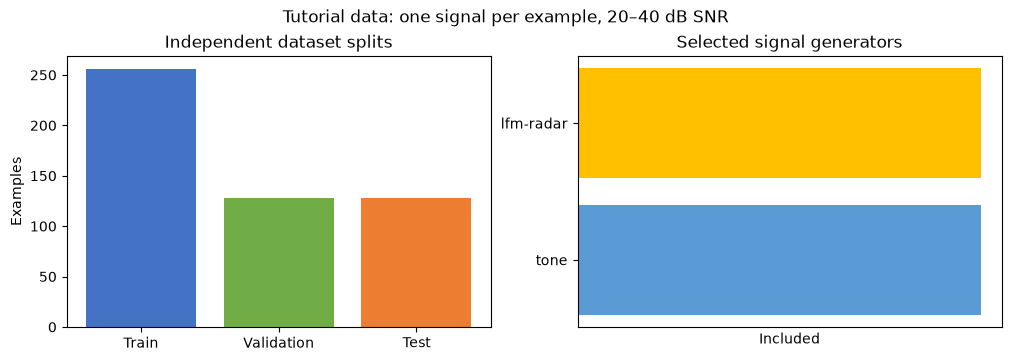

In [6]:
# A quick visual check of the experiment before generating any large files.
split_sizes = {'Train': train_cfg.dataset_length, 'Validation': val_cfg.dataset_length, 'Test': test_cfg.dataset_length}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].bar(list(split_sizes), list(split_sizes.values()), color=['#4472C4', '#70AD47', '#ED7D31'])
axes[0].set(title='Independent dataset splits', ylabel='Examples')
axes[1].barh(SIGNALS, [1] * len(SIGNALS), color=['#5B9BD5', '#FFC000'])
axes[1].set(title='Selected signal generators', xlabel='Included')
axes[1].set_xticks([])
fig.suptitle('Tutorial data: one signal per example, 20–40 dB SNR')
plt.show()

## 3. Use the Training API
Here is the main handoff. `train_efficientnet_iq` creates the static datasets, applies `ComplexTo2D`, builds EfficientNet-B0, trains it, saves the best validation-F1 checkpoint, and evaluates the final model on the test split. We still get the useful pieces back—the PyTorch model, dataloaders, metric trackers, parameter count, and dataset location—so we can inspect or extend the workflow afterward.

Set `RUN_TRAINING = True` when you're ready. Eight epochs and a few hundred examples are enough to exercise the API, but not enough to establish a serious RF result. Full-scale TorchSig datasets can also consume hundreds of gigabytes, so scale deliberately.


> A quick warning about the cache: `overwrite=False` reuses an existing static dataset. If you change the representation, transforms, sample length, or classes, give the experiment a new `dataset_id` or intentionally set `overwrite=True`. For this notebook, a batch should be `[batch, 2, samples]`. A shape like `[batch, frequency, time]` means you picked up a cached spectrogram dataset.

In [7]:
RUN_TRAINING = True  # Set True when you want to generate data and train.

params = {
    'batch_size': 16, 'max_epochs': 8, 'learning_rate': 3e-3,
    'weight_decay': 1e-5, 'drop_path': 0.0, 'drop_rate': 0.0,
    'label_smoothing': 0.0, 'normalize': False,
}

if RUN_TRAINING:
    result = train_efficientnet_iq(
        train_cfg, val_cfg, test_cfg, params,
        checkpoint_dir=RUNS / 'checkpoints',
        metrics_dir=RUNS / 'metrics',
        dataset_root=RUNS / 'datasets',
        overwrite=False, model_name='efficientnet_b0',
        signal_generators=SIGNALS,
    )
    test_accuracy = result['test_metrics'].history['accuracy'][-1]
    print(f"parameters={result['num_params']:,}")
    print(f'test accuracy={test_accuracy:.2%}')
    print(f"data={result['data_info']['root']}")
else:
    print('Training skipped; set RUN_TRAINING=True to run this section.')

Generating Dataset:: 100%|██████████| 8/8 [00:00<00:00, 24.91it/s]
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ NormalizedModel  │  4.0 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.0 M                                                                                                
Total estimated model params size (MB): 15.811                                                                     
Modules in train mode: 322                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_conn
ector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_conn
ector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/pytorch_lightning/loops/fit_loop.py:321: The 
number of training batches (16) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower 
value for log_every_n_steps if you want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=8` reached.


parameters=3,952,801
test accuracy=100.00%
data=runs/v1_iq_tutorial/datasets/efficientnet_iq_tutorial


### Look past the final accuracy
A single accuracy number is useful, but it can hide an imbalanced dataset or one class that consistently fails. The TorchSig Models tracker records loss, accuracy, precision, recall, F1, and confusion matrices, and saves the tables beneath `metrics/`. The plots below make it easier to see whether training improved and whether validation kept pace.

For a real RF evaluation, break results down by class and SNR as well. And remember: strong performance on clean synthetic examples is not proof that the model will work on a radio capture with different filtering, sample rate, interference, or channel effects.

metric fields: ['accuracy', 'f1 score', 'loss', 'precision', 'recall']
repeated accuracy=100.00%


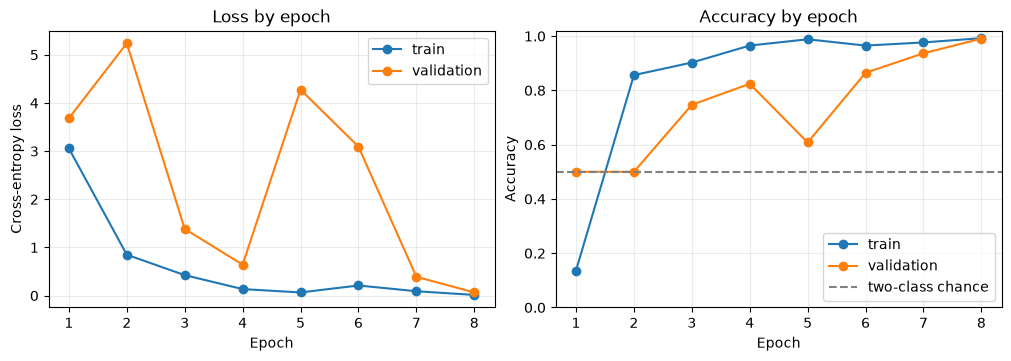

In [8]:
if RUN_TRAINING:
  print('metric fields:', sorted(result['test_metrics'].history))
  # Re-evaluate explicitly when testing a changed criterion or model.
  repeated = evaluate_classifier(
      result['model'], result['test_loader'], DEVICE, result['num_classes']
  )
  print(f"repeated accuracy={repeated.history['accuracy'][-1]:.2%}")

  tracked = result['metrics']
  epochs = range(1, len(tracked.train_losses) + 1)
  fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
  axes[0].plot(epochs, tracked.train_losses, marker='o', label='train')
  axes[0].plot(epochs, tracked.val_losses, marker='o', label='validation')
  axes[0].set(title='Loss by epoch', xlabel='Epoch', ylabel='Cross-entropy loss')
  axes[1].plot(epochs, tracked.train_accuracies, marker='o', label='train')
  axes[1].plot(epochs, tracked.val_accuracies, marker='o', label='validation')
  axes[1].axhline(1 / len(SIGNALS), color='gray', linestyle='--', label='two-class chance')
  axes[1].set(title='Accuracy by epoch', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1.02))
  for axis in axes:
      axis.grid(alpha=0.25)
      axis.legend()
  plt.show()
else:
  print('Metric plots appear here after RUN_TRAINING=True completes.')

## 4. Reload the model for inference
A checkpoint is only useful if we rebuild the same architecture and preprocessing around it. `efficientnet1d_inference` does that for a static IQ dataset, using the checkpoint plus a small parameter YAML.

There is one v1.0 detail worth handling carefully. Restricting `signal_generators` changes which examples are generated, but the released training helper can still build an output for every class in the installed TorchSig registry. That is why a two-signal experiment may produce a checkpoint with 69 outputs. Rather than guessing, the next cell reads the classifier tensor from the checkpoint and uses its actual size.

In [9]:
RUN_INFERENCE = True  # Set True only after selecting the intended checkpoint.

# Example after training; select the checkpoint you intend to deploy.
checkpoints = sorted((RUNS / 'checkpoints').glob('best-*.ckpt'))
checkpoint = checkpoints[-1] if checkpoints else None
static_test_root = RUNS / 'datasets' / 'efficientnet_iq_tutorial' / 'test'
if RUN_INFERENCE and checkpoint is not None:
    params_file = RUNS / 'efficientnet_b0_params.yaml'
    params_file.write_text(yaml.safe_dump(params), encoding='utf-8')
    checkpoint_data = torch.load(checkpoint, map_location='cpu', weights_only=False)
    checkpoint_state = checkpoint_data.get('state_dict', checkpoint_data)
    classifier_weights = [
        value for key, value in checkpoint_state.items()
        if key.endswith('classifier.weight')
    ]
    if len(classifier_weights) != 1:
        raise ValueError('Could not identify one classifier.weight tensor in the checkpoint.')
    checkpoint_num_classes = int(classifier_weights[0].shape[0])
    print(f'Checkpoint output classes: {checkpoint_num_classes}')
    accuracy = efficientnet1d_inference(
        root=static_test_root, checkpoint_path=checkpoint,
        params_path=params_file, batch_size=16, num_workers=0,
        num_classes=checkpoint_num_classes,
        model_name='efficientnet_b0',
    )
elif checkpoint is None:
    print(f"Run training first; no checkpoint found under {RUNS / 'checkpoints'}.")
else:
    print(f'Checkpoint found at {checkpoint}; set RUN_INFERENCE=True to evaluate it.')

Checkpoint output classes: 69


Seed set to 42



Test accuracy: 100.0000%


You've successfully trained a (simple) RFML model using [TorchSig Models](https://github.com/TorchDSP/torchsig-models)!